In [5]:
"""
TASA Silver NAICS/ISIC Emissions Dashboard
Ingests TASA_Silver_NAICS_ISIC.csv and renders an interactive Dash dashboard
with stacked bar charts (Scope 1/2/3) and a 2020-2024 trend view.

Requirements:
    pip install pandas dash plotly
"""
#!pip install panel plotly
#!pip install ipywidgets plotly
#!pip install jupyter_bokeh

import pandas as pd
import numpy as np
import plotly.graph_objects as go



1. Import silver file

In [6]:
def load_data(path: str = "TASA-EFX_rLCA_Abrasive-Material_KOR_2023_v1.0_DEMO.xlsx") -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name="10 Tiers_all_sectors", dtype=str, header = 0)
    return df
df = load_data()
df.head()

,Sectors,Scope 1,Scope 2,Tier 1 Scope 1,Tier 1 Scope 2,Tier 2 Scope 1,Tier 2 Scope 2,Tier 3 Scope 1,Tier 3 Scope 2,Tier 4 Scope 1,...,Tier 6 Scope 1,Tier 6 Scope 2,Tier 7 Scope 1,Tier 7 Scope 2,Tier 8 Scope 1,Tier 8 Scope 2,Tier 9 Scope 1,Tier 9 Scope 2,Tier 10 Scope 1,Tier 10 Scope 2
0,Rice,0,0,0,0,0.02365804754913632,0.0005992009287705846,0.4576075857164619,0.01159008957963562,0.4800253537975875,...,0.203066103552265,0.005143171582423457,0.1325822319112462,0.003357986170866243,0.08716342564277338,0.002207638034858979,0.05619220310677773,0.001423212131995049,0.03542094438542103,0.0008971265582924374
1,"Wheat, Barley, and other Grains",0,0,0,0,0.02814600794032433,0.01717655258333064,0.05418268025025458,0.0330658492812734,0.03136651994598373,...,0.03964603089542537,0.02419462596043659,0.02553441640629389,0.0155827869805651,0.01611723859393143,0.009835803244058888,0.01036330999452347,0.006324376069092986,0.006721603911266876,0.004101966547831011
2,Beans,0,0,0,0,0.02102805393587905,0.006132238559122376,0.02153308673049098,0.006279517122615901,0.0135462631238113,...,0.00756466354511875,0.002206020662664111,0.005244474348224592,0.001529402954670832,0.003359016446344799,0.0009795623615866816,0.002131887566566832,0.0006217048510185015,0.001362012007212175,0.0003971923685416881
3,Potatoes,0,0,0,0,0.007100530359599852,0.001603709812814278,0.007583318974010037,0.001712751363125775,0.00678176244816792,...,0.003196390419530146,0.0007219295491717213,0.002093873495289101,0.0004729175570169801,0.001356757326356511,0.0003064341574068306,0.0008672511016881533,0.0001958753827551642,0.0005466750255550411,0.0001234707914061397
4,Vegetables,0,0,0.004130110456608781,0.000373145379337669,0.1213621585072635,0.01096477422316088,0.1096308131186762,0.009904875856965614,0.07330315012290872,...,0.02997184965641646,0.002707883318616648,0.01965968360341689,0.001776204334709015,0.01276079338199325,0.001152906474826643,0.00809946967545756,0.0007317672774698964,0.005053482141543967,0.0004565697529142811


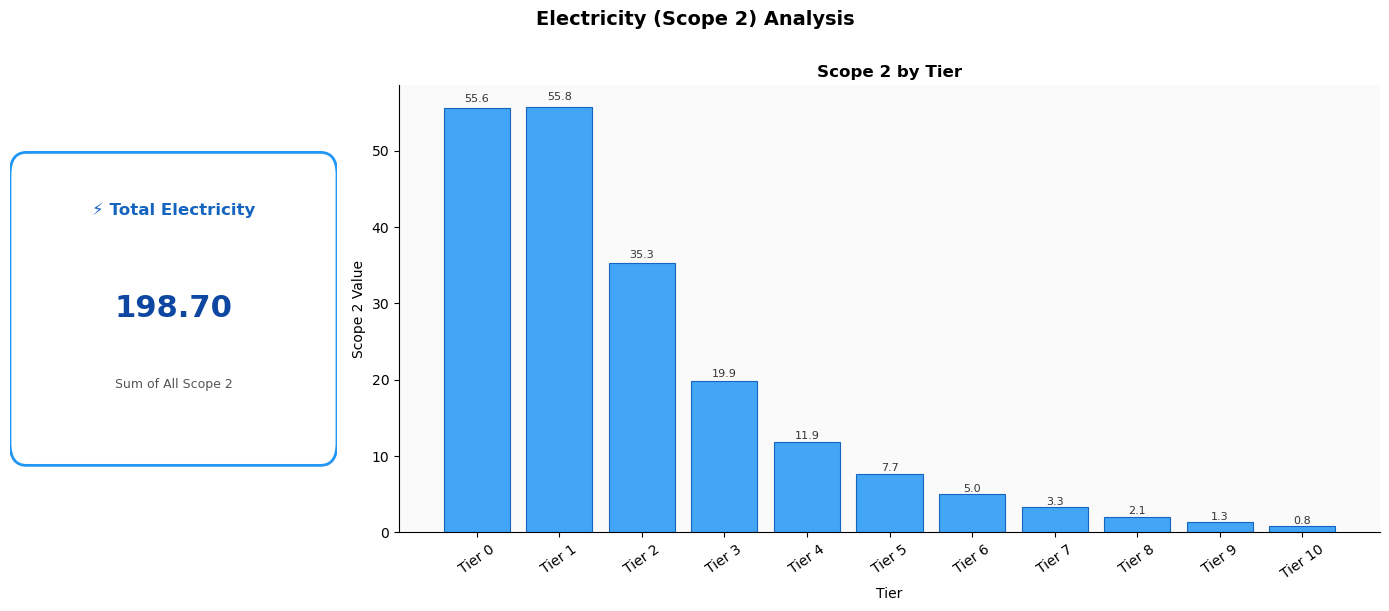

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def load_data(path: str = "TASA-EFX_rLCA_Abrasive-Material_KOR_2023_v1.0_DEMO.xlsx") -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name="10 Tiers_all_sectors", dtype=str, header=0)
    return df

df = load_data()

# Get all Scope 2 columns and convert to numeric
scope2_cols = [col for col in df.columns if "Scope 2" in col]
df[scope2_cols] = df[scope2_cols].apply(pd.to_numeric, errors='coerce')

# Total electricity (sum of all Scope 2)
total_scope2 = df[scope2_cols].values.sum()

# Sum per tier column — rename plain "Scope 2" → "Tier 0"
tier_scope2 = df[scope2_cols].sum()
tier_labels = []
for col in scope2_cols:
    label = col.replace(" Scope 2", "")
    tier_labels.append("Tier 0" if label == "Scope 2" else label)  # <-- rename here

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 3]})
fig.suptitle("Electricity (Scope 2) Analysis", fontsize=14, fontweight='bold', y=1.01)

# --- Callout panel ---
ax0 = axes[0]
ax0.set_facecolor("#EAF4FB")
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
ax0.axis('off')
ax0.add_patch(mpatches.FancyBboxPatch((0.05, 0.2), 0.9, 0.6,
    boxstyle="round,pad=0.05", linewidth=2, edgecolor="#2196F3", facecolor="white"))
ax0.text(0.5, 0.72, "⚡ Total Electricity", ha='center', va='center',
         fontsize=12, color="#1565C0", fontweight='bold')
ax0.text(0.5, 0.50, f"{total_scope2:,.2f}", ha='center', va='center',
         fontsize=22, color="#0D47A1", fontweight='bold')
ax0.text(0.5, 0.33, "Sum of All Scope 2", ha='center', va='center',
         fontsize=9, color="#555")

# --- Bar chart ---
ax1 = axes[1]
bars = ax1.bar(tier_labels, tier_scope2.values, color="#42A5F5", edgecolor="#1565C0", linewidth=0.8)
ax1.set_title("Scope 2 by Tier", fontsize=12, fontweight='bold')
ax1.set_xlabel("Tier")
ax1.set_ylabel("Scope 2 Value")
ax1.tick_params(axis='x', rotation=35)
for bar, val in zip(bars, tier_scope2.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f"{val:,.1f}", ha='center', va='bottom', fontsize=8, color="#333")
ax1.set_facecolor("#FAFAFA")
ax1.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("scope2_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display

def load_data(path: str = "TASA-EFX_rLCA_Abrasive-Material_KOR_2023_v1.0_DEMO.xlsx") -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name="10 Tiers_all_sectors", dtype=str, header=0)
    return df

df = load_data()

# Get all Scope 2 columns and convert to numeric
scope2_cols = [col for col in df.columns if "Scope 2" in col]
df[scope2_cols] = df[scope2_cols].apply(pd.to_numeric, errors='coerce')

# Tier labels — rename plain "Scope 2" → "Tier 0"
tier_labels = []
for col in scope2_cols:
    label = col.replace(" Scope 2", "")
    tier_labels.append("Tier 0" if label == "Scope 2" else label)

# Sector names sorted by Tier 0 (base "Scope 2") descending + "Total" first
sorted_df = df[df["Sectors"].notna()].copy()
sorted_sectors = sorted_df.sort_values("Tier 1 Scope 2", ascending=False)["Sectors"].tolist()
sectors = ["Total"] + sorted_sectors

def get_values(sector):
    if sector == "Total":
        vals = df[scope2_cols].sum().values
        total = vals.sum()
    else:
        row = df[df["Sectors"] == sector]
        vals = row[scope2_cols].values.flatten()
        total = vals.sum()
    return vals, total

def draw(sector):
    vals, total = get_values(sector)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 3]})
    fig.suptitle("Electricity (Scope 2) Analysis", fontsize=14, fontweight='bold')
    ax0, ax1 = axes

    # --- Callout ---
    ax0.set_facecolor("#EAF4FB")
    ax0.set_xlim(0, 1)
    ax0.set_ylim(0, 1)
    ax0.axis('off')
    ax0.add_patch(mpatches.FancyBboxPatch((0.05, 0.2), 0.9, 0.6,
        boxstyle="round,pad=0.05", linewidth=2, edgecolor="#2196F3", facecolor="white"))
    ax0.text(0.5, 0.72, "⚡ Total Electricity", ha='center', va='center',
             fontsize=12, color="#1565C0", fontweight='bold')
    ax0.text(0.5, 0.50, f"{total:,.2f}", ha='center', va='center',
             fontsize=22, color="#0D47A1", fontweight='bold')
    sublabel = "Sum of All Scope 2" if sector == "Total" else sector
    ax0.text(0.5, 0.33, sublabel, ha='center', va='center',
             fontsize=8, color="#555")

    # --- Bar chart ---
    bars = ax1.bar(tier_labels, vals, color="#42A5F5", edgecolor="#1565C0", linewidth=0.8)
    ax1.set_title(f"Scope 2 by Tier — {sector}", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Tier")
    ax1.set_ylabel("Scope 2 Value")
    ax1.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{val:,.1f}", ha='center', va='bottom', fontsize=8, color="#333")
    ax1.set_facecolor("#FAFAFA")
    ax1.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

# --- Dropdown widget ---
dropdown = widgets.Dropdown(
    options=sectors,
    value="Total",
    description="Sector:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

widgets.interactive(draw, sector=dropdown)

interactive(children=(Dropdown(description='Sector:', layout=Layout(width='50%'), options=('Total', 'Basic Ino…

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets

def load_data(path: str = "TASA-EFX_rLCA_Abrasive-Material_KOR_2023_v1.0_DEMO.xlsx") -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name="10 Tiers_all_sectors", dtype=str, header=0)
    return df

df = load_data()

# Get all Scope 1 and Scope 2 columns and convert to numeric
scope1_cols = [col for col in df.columns if "Scope 1" in col]
scope2_cols = [col for col in df.columns if "Scope 2" in col]
df[scope1_cols + scope2_cols] = df[scope1_cols + scope2_cols].apply(pd.to_numeric, errors='coerce')

# Tier labels
def make_tier_labels(cols, base_name):
    labels = []
    for col in cols:
        label = col.replace(f" {base_name}", "")
        labels.append("Tier 0" if label == base_name else label)
    return labels

tier_labels_s1 = make_tier_labels(scope1_cols, "Scope 1")
tier_labels_s2 = make_tier_labels(scope2_cols, "Scope 2")

# Sector names sorted by Tier 1 Scope 2 descending + "Total" first
sorted_df = df[df["Sectors"].notna()].copy()
sorted_sectors = sorted_df.sort_values("Tier 1 Scope 2", ascending=False)["Sectors"].tolist()
sectors = ["Total"] + sorted_sectors

def get_values(sector, cols):
    if sector == "Total":
        vals = df[cols].sum().values
        total = vals.sum()
    else:
        row = df[df["Sectors"] == sector]
        vals = row[cols].values.flatten()
        total = vals.sum()
    return vals, total

def draw(sector):
    vals_s2, total_s2 = get_values(sector, scope2_cols)
    vals_s1, total_s1 = get_values(sector, scope1_cols)

    fig, axes = plt.subplots(2, 2, figsize=(15, 11),
                             gridspec_kw={'width_ratios': [1, 3]})
    fig.suptitle(f"Emissions Analysis — {sector}", fontsize=14, fontweight='bold')

    # ── Row 1: Scope 2 (Electricity) ────────────────────────────────────────
    ax0, ax1 = axes[0]

    ax0.set_facecolor("#EAF4FB")
    ax0.set_xlim(0, 1); ax0.set_ylim(0, 1); ax0.axis('off')
    ax0.add_patch(mpatches.FancyBboxPatch((0.05, 0.2), 0.9, 0.6,
        boxstyle="round,pad=0.05", linewidth=2, edgecolor="#2196F3", facecolor="white"))
    ax0.text(0.5, 0.78, "⚡ Electricity", ha='center', va='center',
             fontsize=12, color="#1565C0", fontweight='bold')
    ax0.text(0.5, 0.55, f"{total_s2:,.2f}", ha='center', va='center',
             fontsize=22, color="#0D47A1", fontweight='bold')
    ax0.text(0.5, 0.35, "Total Scope 2", ha='center', va='center',
             fontsize=9, color="#555")
    sublabel_s2 = "Sum of All Sectors" if sector == "Total" else sector
    ax0.text(0.5, 0.24, sublabel_s2, ha='center', va='center',
             fontsize=7, color="#888")

    bars1 = ax1.bar(tier_labels_s2, vals_s2, color="#42A5F5", edgecolor="#1565C0", linewidth=0.8)
    ax1.set_title("Scope 2 (Electricity) by Tier", fontsize=11, fontweight='bold')
    ax1.set_xlabel("Tier"); ax1.set_ylabel("Scope 2 Value")
    ax1.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars1, vals_s2):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{val:,.1f}", ha='center', va='bottom', fontsize=8, color="#333")
    ax1.set_facecolor("#FAFAFA")
    ax1.spines[['top', 'right']].set_visible(False)

    # ── Row 2: Scope 1 (Direct Emissions) ───────────────────────────────────
    ax2, ax3 = axes[1]

    ax2.set_facecolor("#FFF3E0")
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.axis('off')
    ax2.add_patch(mpatches.FancyBboxPatch((0.05, 0.2), 0.9, 0.6,
        boxstyle="round,pad=0.05", linewidth=2, edgecolor="#FF9800", facecolor="white"))
    ax2.text(0.5, 0.78, "🔥 Direct Emissions", ha='center', va='center',
             fontsize=12, color="#E65100", fontweight='bold')
    ax2.text(0.5, 0.55, f"{total_s1:,.2f}", ha='center', va='center',
             fontsize=22, color="#BF360C", fontweight='bold')
    ax2.text(0.5, 0.35, "Total Scope 1", ha='center', va='center',
             fontsize=9, color="#555")
    sublabel_s1 = "Sum of All Sectors" if sector == "Total" else sector
    ax2.text(0.5, 0.24, sublabel_s1, ha='center', va='center',
             fontsize=7, color="#888")

    bars2 = ax3.bar(tier_labels_s1, vals_s1, color="#FFA726", edgecolor="#E65100", linewidth=0.8)
    ax3.set_title("Scope 1 (Direct Emissions) by Tier", fontsize=11, fontweight='bold')
    ax3.set_xlabel("Tier"); ax3.set_ylabel("Scope 1 Value")
    ax3.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars2, vals_s1):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{val:,.1f}", ha='center', va='bottom', fontsize=8, color="#333")
    ax3.set_facecolor("#FAFAFA")
    ax3.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

# --- Dropdown widget ---
dropdown = widgets.Dropdown(
    options=sectors,
    value="Total",
    description="Sector:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

widgets.interactive(draw, sector=dropdown)

interactive(children=(Dropdown(description='Sector:', layout=Layout(width='50%'), options=('Total', 'Basic Ino…

In [26]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, HTML
import plotly.express as px

def load_data(path: str = "TASA-EFX_rLCA_Abrasive-Material_KOR_2023_v1.0_DEMO.xlsx") -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name="10 Tiers_all_sectors", dtype=str, header=0)
    return df

df = load_data()

scope1_cols = [col for col in df.columns if "Scope 1" in col]
scope2_cols = [col for col in df.columns if "Scope 2" in col]
df[scope1_cols + scope2_cols] = df[scope1_cols + scope2_cols].apply(pd.to_numeric, errors='coerce')

def make_tier_labels(cols, base_name):
    return ["Tier 0" if col.replace(f" {base_name}", "") == base_name
            else col.replace(f" {base_name}", "") for col in cols]

tier_labels_s1 = make_tier_labels(scope1_cols, "Scope 1")
tier_labels_s2 = make_tier_labels(scope2_cols, "Scope 2")

sorted_df = df[df["Sectors"].notna()].copy()
sorted_sectors = sorted_df.sort_values("Tier 1 Scope 2", ascending=False)["Sectors"].tolist()
sectors_list = ["Total"] + sorted_sectors

# Refined earth-tone palette — warm, editorial feel
PALETTE = [
    "#2D4A3E","#4A7C6F","#7FB5A0","#B5D5C8",
    "#8B4513","#C4722A","#E8A96B","#F2CFA0",
    "#1C3A5E","#2E6B9E","#6BAED6","#BDD7EE",
    "#4A2C6E","#7B5EA7","#B39DDB","#D9CCF0",
    "#5C2D2D","#9E4A4A","#D47F7F","#F0BABA",
    "#2D4A1E","#5C8A3A","#95C26A","#C8E6A0",
    "#4A3D00","#8B7000","#D4AA00","#F5E070",
    "#1A3A3A","#2E7D7D","#5BB8B8","#A8DCDC",
]
sector_colors = {s: PALETTE[i % len(PALETTE)] for i, s in enumerate(sorted_sectors)}

# Inject Google Font
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=DM+Serif+Display:ital@0;1&family=DM+Sans:wght@300;400;500&display=swap');
.widget-dropdown select, .widget-label {
    font-family: 'DM Sans', sans-serif !important;
    font-size: 13px !important;
    color: #1a1a2e !important;
}
.dropdown-label {
    font-family: 'DM Serif Display', serif;
    font-size: 18px;
    color: #1a1a2e;
    letter-spacing: 0.5px;
    margin-bottom: 4px;
}
</style>
"""))

BG        = "#F7F4EF"   # warm parchment
PANEL_BG  = "#FFFFFF"
GRID_COL  = "#E8E2D9"
TITLE_COL = "#1A1A2E"
SUB_COL   = "#6B6560"
S2_ACCENT = "#2E6B9E"
S1_ACCENT = "#C4722A"

def build_figure(selected_sector):
    plot_df = df[df["Sectors"].notna()].copy() if selected_sector == "Total" \
              else df[df["Sectors"] == selected_sector].copy()

    col_totals_s2 = plot_df[scope2_cols].sum()
    col_totals_s1 = plot_df[scope1_cols].sum()
    total_s2 = col_totals_s2.sum()
    total_s1 = col_totals_s1.sum()

    fig = make_subplots(
        rows=1, cols=2,
        horizontal_spacing=0.10,
    )

    for _, row in plot_df.iterrows():
        sname = row["Sectors"]
        color = sector_colors.get(sname, "#888888")

        # Scope 2
        s2_vals = [row[c] for c in scope2_cols]
        hover_s2 = []
        for t, v, c in zip(tier_labels_s2, s2_vals, scope2_cols):
            pct = (v / col_totals_s2[c] * 100) if pd.notna(v) and col_totals_s2[c] > 0 else 0
            hover_s2.append(
                f"<span style='font-family:DM Sans'>"
                f"<b style='font-size:14px'>{sname}</b><br>"
                f"<span style='color:#6B6560'>{t}</span><br>"
                f"<b>{v:,.2f}</b><br>"
                f"<span style='color:{S2_ACCENT}'>▪ {pct:.1f}% of tier</span>"
                f"</span>"
            )

        fig.add_trace(go.Bar(
            name=sname, x=tier_labels_s2, y=s2_vals,
            marker_color=color,
            marker_line_width=0,
            hovertemplate="%{customdata}<extra></extra>",
            customdata=hover_s2,
            legendgroup=sname,
            showlegend=True,
        ), row=1, col=1)

        # Scope 1
        s1_vals = [row[c] for c in scope1_cols]
        hover_s1 = []
        for t, v, c in zip(tier_labels_s1, s1_vals, scope1_cols):
            pct = (v / col_totals_s1[c] * 100) if pd.notna(v) and col_totals_s1[c] > 0 else 0
            hover_s1.append(
                f"<span style='font-family:DM Sans'>"
                f"<b style='font-size:14px'>{sname}</b><br>"
                f"<span style='color:#6B6560'>{t}</span><br>"
                f"<b>{v:,.2f}</b><br>"
                f"<span style='color:{S1_ACCENT}'>▪ {pct:.1f}% of tier</span>"
                f"</span>"
            )

        fig.add_trace(go.Bar(
            name=sname, x=tier_labels_s1, y=s1_vals,
            marker_color=color,
            marker_line_width=0,
            hovertemplate="%{customdata}<extra></extra>",
            customdata=hover_s1,
            legendgroup=sname,
            showlegend=False,
        ), row=1, col=2)

    label = selected_sector if selected_sector != "Total" else "All Sectors"

    fig.update_layout(
        barmode="stack",
        height=560,
        margin=dict(t=110, b=60, l=60, r=180),
        paper_bgcolor=BG,
        plot_bgcolor=PANEL_BG,

        title=dict(
            text=(
                f"<span style='font-family:DM Serif Display,serif;"
                f"font-size:22px;color:{TITLE_COL}'>{label}</span><br>"
                f"<span style='font-family:DM Sans,sans-serif;"
                f"font-size:12px;color:{SUB_COL}'>"
                f"⚡ Electricity &nbsp;<b style='color:{S2_ACCENT}'>{total_s2:,.1f}</b>"
                f"&nbsp;&nbsp;&nbsp;🔥 Direct Emissions &nbsp;<b style='color:{S1_ACCENT}'>{total_s1:,.1f}</b>"
                f"</span>"
            ),
            x=0.0, xanchor="left",
            y=0.97, yanchor="top",
            pad=dict(l=10),
        ),

        legend=dict(
            title=dict(
                text="<span style='font-family:DM Sans;font-size:11px;"
                     f"color:{SUB_COL}'>SECTOR</span>",
            ),
            font=dict(family="DM Sans", size=10, color=TITLE_COL),
            bgcolor="rgba(247,244,239,0.9)",
            bordercolor=GRID_COL,
            borderwidth=1,
            x=1.01, y=1,
            orientation="v",
        ),

        hovermode="closest",
        hoverlabel=dict(
            bgcolor=PANEL_BG,
            bordercolor=GRID_COL,
            font=dict(family="DM Sans", size=12, color=TITLE_COL),
        ),

        xaxis=dict(
            title=dict(text="<span style='font-family:DM Sans;font-size:11px;"
                       f"color:{SUB_COL}'>TIER — SCOPE 2 · ELECTRICITY</span>"),
            tickfont=dict(family="DM Sans", size=10, color=SUB_COL),
            tickangle=-30,
            gridcolor=GRID_COL, gridwidth=1,
            linecolor=GRID_COL,
            zeroline=False,
        ),
        xaxis2=dict(
            title=dict(text="<span style='font-family:DM Sans;font-size:11px;"
                       f"color:{SUB_COL}'>TIER — SCOPE 1 · DIRECT EMISSIONS</span>"),
            tickfont=dict(family="DM Sans", size=10, color=SUB_COL),
            tickangle=-30,
            gridcolor=GRID_COL, gridwidth=1,
            linecolor=GRID_COL,
            zeroline=False,
        ),
        yaxis=dict(
            tickfont=dict(family="DM Sans", size=10, color=SUB_COL),
            gridcolor=GRID_COL, gridwidth=1,
            linecolor=GRID_COL,
            zeroline=False,
        ),
        yaxis2=dict(
            tickfont=dict(family="DM Sans", size=10, color=SUB_COL),
            gridcolor=GRID_COL, gridwidth=1,
            linecolor=GRID_COL,
            zeroline=False,
        ),

        # Thin accent line above each chart title
        shapes=[
            dict(type="line", xref="paper", yref="paper",
                 x0=0, x1=0.44, y0=1.04, y1=1.04,
                 line=dict(color=S2_ACCENT, width=2)),
            dict(type="line", xref="paper", yref="paper",
                 x0=0.56, x1=1.0, y0=1.04, y1=1.04,
                 line=dict(color=S1_ACCENT, width=2)),
        ],

        annotations=[
            dict(text="<b>SCOPE 2</b> · Electricity",
                 xref="paper", yref="paper",
                 x=0.22, y=1.07, showarrow=False,
                 font=dict(family="DM Sans", size=11, color=S2_ACCENT),
                 xanchor="center"),
            dict(text="<b>SCOPE 1</b> · Direct Emissions",
                 xref="paper", yref="paper",
                 x=0.78, y=1.07, showarrow=False,
                 font=dict(family="DM Sans", size=11, color=S1_ACCENT),
                 xanchor="center"),
        ],
    )

    fig.update_traces(marker_opacity=0.88)
    return fig

# ── Styled dropdown ──
display(HTML("<div class='dropdown-label'>Emissions by Sector</div>"))

dropdown = widgets.Dropdown(
    options=sectors_list,
    value="Total",
    description="",
    layout=widgets.Layout(width="340px"),
)

out = widgets.Output()

def on_change(change):
    if change["name"] == "value":
        with out:
            out.clear_output(wait=True)
            build_figure(change["new"]).show()

dropdown.observe(on_change, names="value")
display(dropdown, out)

with out:
    build_figure("Total").show()

Dropdown(layout=Layout(width='340px'), options=('Total', 'Basic Inorganic Compounds', 'Other Fiber Fabrics', '…

Output()